# Cyberbullying Tweet Multiclass Classifier — RoBERTa

**Course:** WQF7007 Natural Language Processing | University of Malaya, Master of Data Science  
**Approach:** TF-IDF Baselines + Fine-Tuned RoBERTa (2 Variations)  
**Dataset:** Cyberbullying Tweets — 6 classes, ~47,692 samples  

---

## Why RoBERTa over DistilBERT?

| | DistilBERT | RoBERTa-base |
|---|---|---|
| Parameters | 66M | 125M |
| Pretraining data | Same as BERT | 10x more data (160GB) |
| NSP task | Yes (inherited) | Removed — trains better without it |
| Social media text | Decent | Stronger — more robust tokenization |
| Dynamic masking | No | Yes — sees different masks each epoch |

## Two Variations

| Variation | Model | Notes |
|---|---|---|
| **V1** | `roberta-base` | General purpose, standard fine-tune |
| **V2** | `cardiffnlp/twitter-roberta-base` | Pre-trained on 58M tweets — domain-specific |

---

## Pipeline Overview

```
cyberbullying_tweets.csv
         │
         ▼
[0] Environment Setup
         │
         ▼
[1] Load & Explore Data (EDA)
         │
         ▼
[2] Preprocessing & Train/Val/Test Split
         │
         ▼
[3] Baseline — TF-IDF + Logistic Regression & SVM
         │
         ▼
[4a] RoBERTa-base (V1 — General)
         │
         ▼
[4b] Twitter-RoBERTa-base (V2 — Domain-Specific)
         │
         ▼
[5] Evaluation & Comparison
```

---
## Section 0 — Environment Setup

In [2]:
# Install required packages (safe to re-run — skips already installed)
!pip install -q transformers datasets accelerate
!pip install -q scikit-learn pandas numpy torch

In [3]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

# ── GPU check ──────────────────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {device}")
if device == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU found — training will be very slow on CPU.")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [6]:
# ── Path Configuration (Kaggle) ────────────────────────────────────────────
DATASET_PATH = '/kaggle/input/datasets/faizyah/cyberbulling-tweet/cyberbullying_tweets.csv'
OUTPUT_DIR_V1 = '/kaggle/working/roberta-base-cyberbullying'
OUTPUT_DIR_V2 = '/kaggle/working/twitter-roberta-cyberbullying'

# ── Model names ────────────────────────────────────────────────────────────
MODEL_V1 = 'roberta-base'                            # V1 — general RoBERTa
MODEL_V2 = 'cardiffnlp/twitter-roberta-base'         # V2 — tweet-pretrained RoBERTa

# ── Training Constants ─────────────────────────────────────────────────────
MAX_LEN    = 128
BATCH_SIZE = 16     # RoBERTa is larger than DistilBERT — reduce batch size
EPOCHS     = 4
LR         = 2e-5
SEED       = 42

print("Configuration loaded.")
print(f"  V1 model     : {MODEL_V1}")
print(f"  V2 model     : {MODEL_V2}")
print(f"  Max length   : {MAX_LEN}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Learning rate: {LR}")
print(f"  Epochs       : {EPOCHS}")

Configuration loaded.
  V1 model     : roberta-base
  V2 model     : cardiffnlp/twitter-roberta-base
  Max length   : 128
  Batch size   : 16
  Learning rate: 2e-05
  Epochs       : 4


---
## Section 1 — Load & Explore Data (EDA)

In [7]:
df = pd.read_csv(DATASET_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (47692, 2)
Columns: ['tweet_text', 'cyberbullying_type']


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


Class distribution:
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


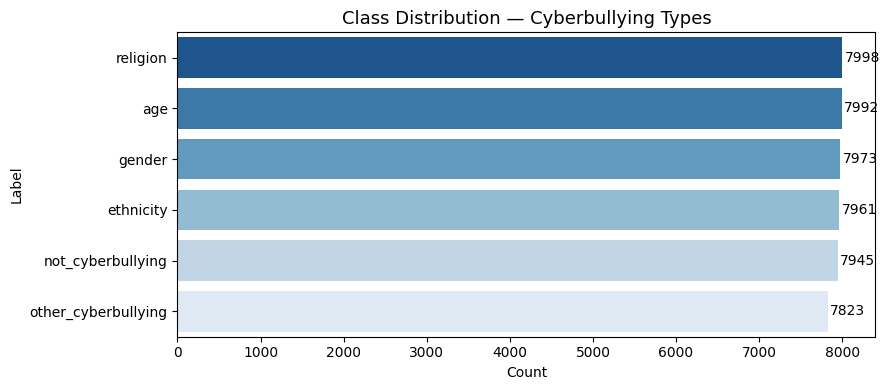

In [8]:
# ── Class distribution ─────────────────────────────────────────────────────
label_counts = df['cyberbullying_type'].value_counts()
print("Class distribution:")
print(label_counts)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=label_counts.values, y=label_counts.index, palette='Blues_r', ax=ax)
ax.set_title('Class Distribution — Cyberbullying Types', fontsize=13)
ax.set_xlabel('Count')
ax.set_ylabel('Label')
for i, v in enumerate(label_counts.values):
    ax.text(v + 30, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.show()

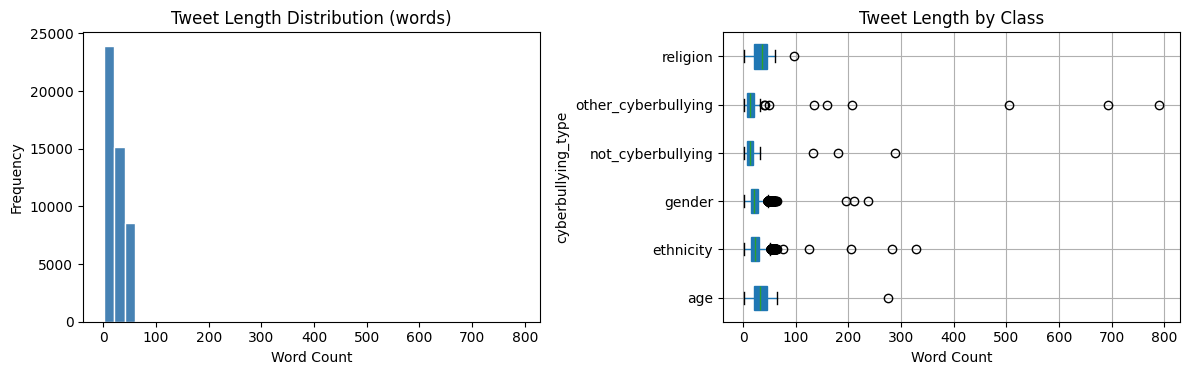

count    47692.000000
mean        23.704835
std         15.434881
min          1.000000
25%         13.000000
50%         20.000000
75%         32.000000
max        790.000000
Name: tweet_len, dtype: float64


In [9]:
# ── Tweet length distribution ──────────────────────────────────────────────
df['tweet_len'] = df['tweet_text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['tweet_len'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Tweet Length Distribution (words)')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

df.boxplot(column='tweet_len', by='cyberbullying_type', ax=axes[1],
           vert=False, patch_artist=True)
axes[1].set_title('Tweet Length by Class')
axes[1].set_xlabel('Word Count')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(df['tweet_len'].describe())

---
## Section 2 — Preprocessing & Train/Val/Test Split

In [10]:
def clean_tweet(text: str) -> str:
    """Basic tweet cleaning — remove URLs, mentions, extra whitespace."""
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'@\w+', '', text)                  # remove @mentions
    text = re.sub(r'#', '', text)                     # keep hashtag words, remove #
    text = re.sub(r'[^\w\s!?.,]', ' ', text)          # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()          # collapse whitespace
    return text.lower()

df = df.dropna(subset=['tweet_text', 'cyberbullying_type'])
df['tweet_clean'] = df['tweet_text'].apply(clean_tweet)

# Remove empty rows after cleaning
df = df[df['tweet_clean'].str.len() > 3].reset_index(drop=True)
print(f"Rows after cleaning: {len(df)}")
df[['tweet_text', 'tweet_clean', 'cyberbullying_type']].head(3)

Rows after cleaning: 47307


,tweet_text,tweet_clean,cyberbullying_type
0,"In other words #katandandre, your food was cra...","in other words katandandre, your food was crap...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,why is aussietv so white? mkr theblock imacele...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,a classy whore? or more red velvet cupcakes?,not_cyberbullying


In [11]:
# ── Label encoding ─────────────────────────────────────────────────────────
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['cyberbullying_type'])

num_labels = len(label_encoder.classes_)
id2label   = {i: l for i, l in enumerate(label_encoder.classes_)}
label2id   = {l: i for i, l in id2label.items()}

print(f"Number of classes: {num_labels}")
print(f"Label mapping: {id2label}")

# ── Train / Val / Test split  70 / 15 / 15 ────────────────────────────────
X = df['tweet_clean'].values
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"\nTrain : {len(X_train)}")
print(f"Val   : {len(X_val)}")
print(f"Test  : {len(X_test)}")

Number of classes: 6
Label mapping: {0: 'age', 1: 'ethnicity', 2: 'gender', 3: 'not_cyberbullying', 4: 'other_cyberbullying', 5: 'religion'}

Train : 33114
Val   : 7096
Test  : 7097


---
## Section 3 — Baseline: TF-IDF + Classical ML

In [12]:
# ── TF-IDF Vectorizer ─────────────────────────────────────────────────────
# unigrams + bigrams, top 50k features, log-normalized TF
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50_000,
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word',
    min_df=2,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")

TF-IDF matrix shape (train): (33114, 50000)


In [13]:
# ── Baseline 1: Logistic Regression ───────────────────────────────────────
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED, n_jobs=-1)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)
lr_f1     = f1_score(y_test, y_pred_lr, average='macro')

print("[Baseline 1] Logistic Regression — Test Set")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))
print(f"Macro F1: {lr_f1:.4f}")

[Baseline 1] Logistic Regression — Test Set
                     precision    recall  f1-score   support

                age       0.96      0.98      0.97      1199
          ethnicity       0.98      0.98      0.98      1194
             gender       0.91      0.81      0.86      1192
  not_cyberbullying       0.60      0.55      0.57      1174
other_cyberbullying       0.59      0.66      0.62      1138
           religion       0.93      0.96      0.95      1200

           accuracy                           0.83      7097
          macro avg       0.83      0.82      0.82      7097
       weighted avg       0.83      0.83      0.83      7097

Macro F1: 0.8249


In [14]:
# ── Baseline 2: Linear SVM ────────────────────────────────────────────────
svm = LinearSVC(C=1.0, max_iter=2000, random_state=SEED)
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)
svm_f1     = f1_score(y_test, y_pred_svm, average='macro')

print("[Baseline 2] Linear SVM — Test Set")
print(classification_report(y_test, y_pred_svm, target_names=label_encoder.classes_))
print(f"Macro F1: {svm_f1:.4f}")

[Baseline 2] Linear SVM — Test Set
                     precision    recall  f1-score   support

                age       0.96      0.99      0.97      1199
          ethnicity       0.97      0.98      0.98      1194
             gender       0.88      0.85      0.86      1192
  not_cyberbullying       0.58      0.53      0.55      1174
other_cyberbullying       0.56      0.60      0.58      1138
           religion       0.95      0.96      0.96      1200

           accuracy                           0.82      7097
          macro avg       0.82      0.82      0.82      7097
       weighted avg       0.82      0.82      0.82      7097

Macro F1: 0.8165


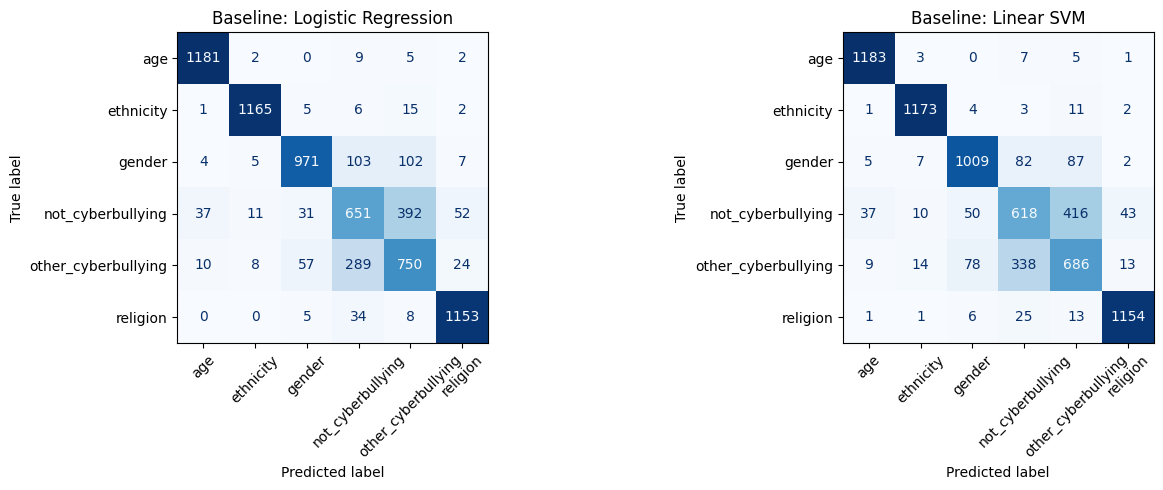

In [15]:
# ── Confusion matrices for both baselines ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_svm],
    ['Logistic Regression', 'Linear SVM']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
    ax.set_title(f'Baseline: {title}')

plt.tight_layout()
plt.show()

---
## Section 4a — V1: Fine-Tuned `roberta-base`

`roberta-base` is a robustly optimized BERT — trained on 10x more data than BERT, with dynamic masking and no Next Sentence Prediction task. Good general-purpose encoder for classification.

In [16]:
# ── Tokenizer V1 ──────────────────────────────────────────────────────────
tokenizer_v1 = AutoTokenizer.from_pretrained(MODEL_V1)

# ── PyTorch Dataset ────────────────────────────────────────────────────────
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding='max_length',
            max_length=MAX_LEN,
            return_tensors='pt',
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

train_ds_v1 = TweetDataset(X_train, y_train, tokenizer_v1)
val_ds_v1   = TweetDataset(X_val,   y_val,   tokenizer_v1)
test_ds_v1  = TweetDataset(X_test,  y_test,  tokenizer_v1)

print(f"Train: {len(train_ds_v1)} | Val: {len(val_ds_v1)} | Test: {len(test_ds_v1)}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 33114 | Val: 7096 | Test: 7097


In [17]:
# ── Model V1 ───────────────────────────────────────────────────────────────
model_v1 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_V1,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)

total_params = sum(p.numel() for p in model_v1.parameters())
print(f"Total parameters: {total_params:,}")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 124,650,246


In [18]:
# ── Evaluation metrics ─────────────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds    = np.argmax(logits, axis=-1)
    macro_f1 = f1_score(labels, preds, average='macro')
    accuracy = (preds == labels).mean()
    return {'macro_f1': macro_f1, 'accuracy': accuracy}

In [19]:
# ── Training Arguments V1 ──────────────────────────────────────────────────
training_args_v1 = TrainingArguments(
    output_dir=OUTPUT_DIR_V1,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=64,
    learning_rate=LR,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    logging_dir='./logs_v1',
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to='none',
)

trainer_v1 = Trainer(
    model=model_v1,
    args=training_args_v1,
    train_dataset=train_ds_v1,
    eval_dataset=val_ds_v1,
    compute_metrics=compute_metrics,
)

print("[V1] Starting training — roberta-base...")
trainer_v1.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


[V1] Starting training — roberta-base...


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.817684,0.759009,0.844124,0.847379
2,0.677777,0.672031,0.865109,0.866685
3,0.555102,0.680536,0.863102,0.866545
4,0.441514,0.723834,0.861114,0.864853


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=4140, training_loss=0.7376449958137844, metrics={'train_runtime': 1967.8002, 'train_samples_per_second': 67.312, 'train_steps_per_second': 2.104, 'total_flos': 8712972397006848.0, 'train_loss': 0.7376449958137844, 'epoch': 4.0})

In [20]:
# ── V1 Test Set Evaluation ─────────────────────────────────────────────────
preds_v1    = trainer_v1.predict(test_ds_v1)
y_pred_v1   = np.argmax(preds_v1.predictions, axis=-1)
v1_f1       = f1_score(y_test, y_pred_v1, average='macro')

print("[V1] roberta-base — Test Set")
print(classification_report(y_test, y_pred_v1, target_names=label_encoder.classes_))
print(f"Macro F1: {v1_f1:.4f}")

# Save model
trainer_v1.save_model(OUTPUT_DIR_V1)
tokenizer_v1.save_pretrained(OUTPUT_DIR_V1)
print(f"Model saved to: {OUTPUT_DIR_V1}")

[V1] roberta-base — Test Set
                     precision    recall  f1-score   support

                age       0.99      0.97      0.98      1199
          ethnicity       0.98      0.98      0.98      1194
             gender       0.90      0.85      0.87      1192
  not_cyberbullying       0.68      0.59      0.63      1174
other_cyberbullying       0.64      0.77      0.70      1138
           religion       0.96      0.98      0.97      1200

           accuracy                           0.86      7097
          macro avg       0.86      0.86      0.86      7097
       weighted avg       0.86      0.86      0.86      7097

Macro F1: 0.8568


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /kaggle/working/roberta-base-cyberbullying


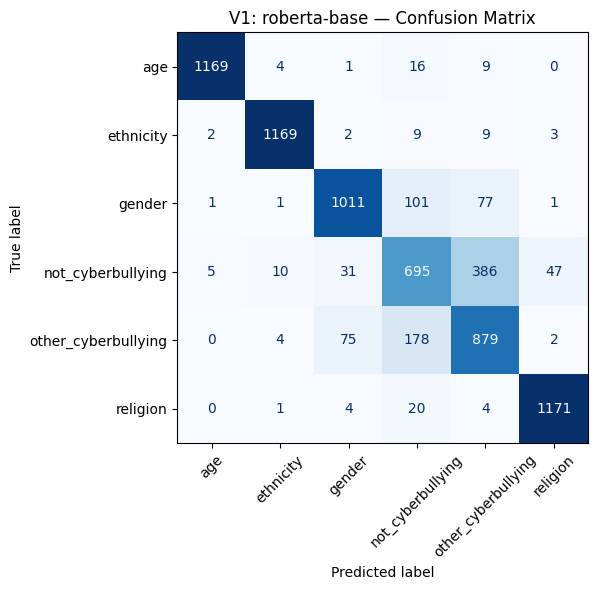

In [21]:
# ── V1 Confusion Matrix ────────────────────────────────────────────────────
cm_v1 = confusion_matrix(y_test, y_pred_v1)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm_v1, display_labels=label_encoder.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
ax.set_title('V1: roberta-base — Confusion Matrix')
plt.tight_layout()
plt.show()

---
## Section 4b — V2: Fine-Tuned `twitter-roberta-base`

`cardiffnlp/twitter-roberta-base` is RoBERTa pretrained specifically on **58 million tweets** — it already understands tweet slang, hashtags, and informal language before fine-tuning even begins. This gives it a head start on social media text like cyberbullying tweets.

In [22]:
# ── Tokenizer V2 ──────────────────────────────────────────────────────────
# Twitter-RoBERTa uses a different tokenizer — must load separately
tokenizer_v2 = AutoTokenizer.from_pretrained(MODEL_V2)

train_ds_v2 = TweetDataset(X_train, y_train, tokenizer_v2)
val_ds_v2   = TweetDataset(X_val,   y_val,   tokenizer_v2)
test_ds_v2  = TweetDataset(X_test,  y_test,  tokenizer_v2)

print(f"Train: {len(train_ds_v2)} | Val: {len(val_ds_v2)} | Test: {len(test_ds_v2)}")

config.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Train: 33114 | Val: 7096 | Test: 7097


In [23]:
# ── Model V2 ───────────────────────────────────────────────────────────────
model_v2 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_V2,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,   # needed — original head size differs
)

total_params = sum(p.numel() for p in model_v2.parameters())
print(f"Total parameters: {total_params:,}")

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 124,650,246


In [24]:
# ── Training Arguments V2 ──────────────────────────────────────────────────
training_args_v2 = TrainingArguments(
    output_dir=OUTPUT_DIR_V2,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=64,
    learning_rate=LR,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    logging_dir='./logs_v2',
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to='none',
)

trainer_v2 = Trainer(
    model=model_v2,
    args=training_args_v2,
    train_dataset=train_ds_v2,
    eval_dataset=val_ds_v2,
    compute_metrics=compute_metrics,
)

print("[V2] Starting training — twitter-roberta-base...")
trainer_v2.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

[V2] Starting training — twitter-roberta-base...


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.760116,0.732872,0.854325,0.856257
2,0.628330,0.669007,0.864216,0.866545
3,0.486064,0.712282,0.859766,0.864572
4,0.381966,0.782758,0.855508,0.859921


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=4140, training_loss=0.6825564815226385, metrics={'train_runtime': 1974.5403, 'train_samples_per_second': 67.082, 'train_steps_per_second': 2.097, 'total_flos': 8712972397006848.0, 'train_loss': 0.6825564815226385, 'epoch': 4.0})

In [25]:
# ── V2 Test Set Evaluation ─────────────────────────────────────────────────
preds_v2    = trainer_v2.predict(test_ds_v2)
y_pred_v2   = np.argmax(preds_v2.predictions, axis=-1)
v2_f1       = f1_score(y_test, y_pred_v2, average='macro')

print("[V2] twitter-roberta-base — Test Set")
print(classification_report(y_test, y_pred_v2, target_names=label_encoder.classes_))
print(f"Macro F1: {v2_f1:.4f}")

# Save model
trainer_v2.save_model(OUTPUT_DIR_V2)
tokenizer_v2.save_pretrained(OUTPUT_DIR_V2)
print(f"Model saved to: {OUTPUT_DIR_V2}")

[V2] twitter-roberta-base — Test Set
                     precision    recall  f1-score   support

                age       0.99      0.97      0.98      1199
          ethnicity       0.99      0.98      0.98      1194
             gender       0.89      0.87      0.88      1192
  not_cyberbullying       0.71      0.59      0.65      1174
other_cyberbullying       0.66      0.79      0.71      1138
           religion       0.94      0.98      0.96      1200

           accuracy                           0.86      7097
          macro avg       0.86      0.86      0.86      7097
       weighted avg       0.87      0.86      0.86      7097

Macro F1: 0.8615


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /kaggle/working/twitter-roberta-cyberbullying


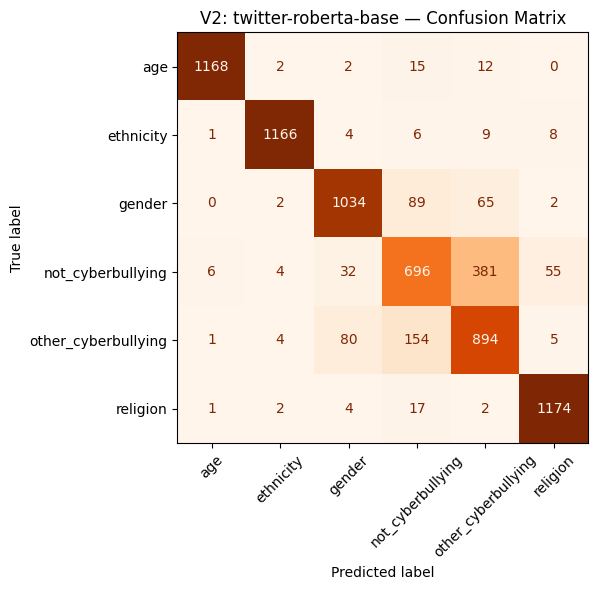

In [26]:
# ── V2 Confusion Matrix ────────────────────────────────────────────────────
cm_v2 = confusion_matrix(y_test, y_pred_v2)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm_v2, display_labels=label_encoder.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Oranges', xticks_rotation=45)
ax.set_title('V2: twitter-roberta-base — Confusion Matrix')
plt.tight_layout()
plt.show()

---
## Section 5 — Evaluation & Comparison

In [27]:
# ── Summary comparison table ──────────────────────────────────────────────
summary = pd.DataFrame({
    'Model'      : [
        'TF-IDF + Logistic Regression',
        'TF-IDF + Linear SVM',
        'roberta-base (V1)',
        'twitter-roberta-base (V2)',
    ],
    'Type'       : ['Baseline', 'Baseline', 'Transformer', 'Transformer'],
    'Parameters' : ['N/A', 'N/A', '125M', '125M'],
    'Macro F1'   : [
        round(lr_f1,  4),
        round(svm_f1, 4),
        round(v1_f1,  4),
        round(v2_f1,  4),
    ],
})

print("=" * 65)
print("RESULTS SUMMARY")
print("=" * 65)
print(summary.to_string(index=False))

RESULTS SUMMARY
                       Model        Type Parameters  Macro F1
TF-IDF + Logistic Regression    Baseline        N/A    0.8249
         TF-IDF + Linear SVM    Baseline        N/A    0.8165
           roberta-base (V1) Transformer       125M    0.8568
   twitter-roberta-base (V2) Transformer       125M    0.8615


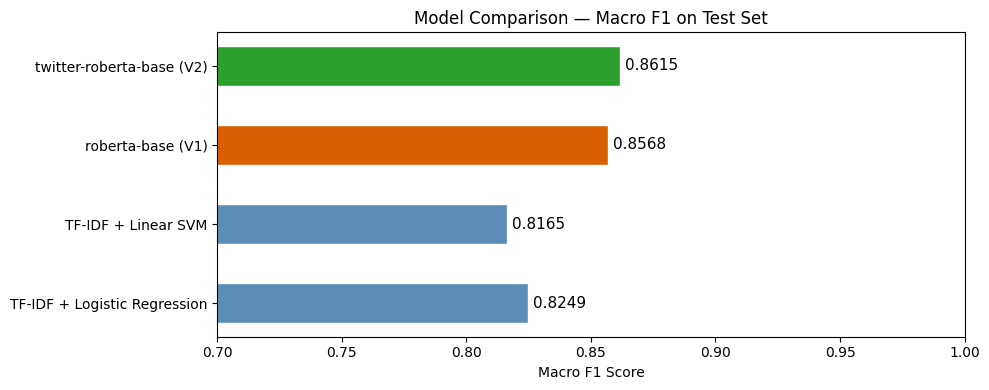

In [28]:
# ── Bar chart comparison ──────────────────────────────────────────────────
models  = summary['Model'].tolist()
f1_vals = summary['Macro F1'].tolist()
colors  = ['#5b8db8', '#5b8db8', '#d95f02', '#2ca02c']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(models, f1_vals, color=colors, edgecolor='white', height=0.5)
ax.set_xlim(0.7, 1.0)
ax.set_xlabel('Macro F1 Score')
ax.set_title('Model Comparison — Macro F1 on Test Set')
for bar, val in zip(bars, f1_vals):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=11)
plt.tight_layout()
plt.show()

---
## Conclusion

### What was built

| Step | Component | Detail |
|------|-----------|--------|
| 1 | **EDA** | Class distribution, tweet length analysis |
| 2 | **Preprocessing** | URL/mention removal, lowercasing, 70/15/15 stratified split |
| 3 | **Baseline** | TF-IDF (unigrams+bigrams) + Logistic Regression & Linear SVM |
| 4a | **V1 — roberta-base** | General-purpose RoBERTa, fine-tuned on cyberbullying tweets |
| 4b | **V2 — twitter-roberta-base** | Domain-specific RoBERTa pretrained on 58M tweets |
| 5 | **Evaluation** | Per-class classification report + Macro F1 + confusion matrices |

### V1 vs V2 — What to expect

V2 (`twitter-roberta-base`) should outperform V1 (`roberta-base`) because:
- It was **pretrained on tweets** — already understands informal language, slang, abbreviations
- Its tokenizer handles **@mentions, hashtags, and emojis** better
- Less domain shift between pretraining data and fine-tuning data

### Next steps

- Try `hate-speech-CNERG/bert-base-uncased-hatexplain` — specifically trained on hate speech datasets
- Experiment with longer `MAX_LEN` (256) to capture more tweet context
- Error analysis — inspect misclassified examples per class
- Ensemble V1 + V2 predictions for potentially higher F1